# Fine-Tuning a Vision Transformer with LoRA
### Image Classification | Hugging Face `transformers` + `peft`

This notebook trains a **real LoRA adapter from scratch** for image classification.
We freeze a pretrained Vision Transformer (ViT) and train only small low-rank
matrices inserted into its attention layers — a genuine training loop with
gradients, loss, and an optimizer, not adapter *loading*.

**What this notebook does:**
- Loads the `beans` dataset (leaf images, 3 disease/health classes)
- Loads a pretrained `google/vit-base-patch16-224-in21k` model
- Freezes the base ViT and attaches trainable LoRA adapters via `peft.LoraConfig`
- Trains with `transformers.Trainer` — forward pass, loss, backward pass, optimizer step
- Saves the trained adapter and reloads it (merged) for inference

**Recommended environment:** Google Colab with a GPU runtime
(`Runtime -> Change runtime type -> T4 GPU` or better).


## Step 0 — Install Dependencies

In [2]:
%pip install -q -U transformers datasets accelerate evaluate
%pip install -q -U "peft"
%pip install -q -U torch torchvision --extra-index-url https://download.pytorch.org/whl/cu121

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


## Step 1 — Imports

In [3]:
import numpy as np
import torch
from datasets import load_dataset
import evaluate

from transformers import (
    AutoImageProcessor,
    AutoModelForImageClassification,
    TrainingArguments,
    Trainer,
)
from peft import LoraConfig, get_peft_model, PeftModel

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)


Using device: cpu


## Step 2 — Load the Training Dataset

`beans` is a small, well-behaved image classification dataset (leaf photos,
3 classes: healthy, angular leaf spot, bean rust) — good for a quick,
real training run.


In [5]:
dataset = load_dataset("AI-Lab-Makerere/beans")

labels = dataset["train"].features["labels"].names
label2id = {label: i for i, label in enumerate(labels)}
id2label = {i: label for i, label in enumerate(labels)}

print(dataset)
print("Classes:", labels)


README.md:   0%|          | 0.00/4.95k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  144MB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

data/validation-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 18.5MB            

data/validation-00000-of-00001.parquet: downloading bytes:           |  0.00B            

...

data/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/1034 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/133 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/128 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['image_file_path', 'image', 'labels'],
        num_rows: 1034
    })
    validation: Dataset({
        features: ['image_file_path', 'image', 'labels'],
        num_rows: 133
    })
    test: Dataset({
        features: ['image_file_path', 'image', 'labels'],
        num_rows: 128
    })
})
Classes: ['angular_leaf_spot', 'bean_rust', 'healthy']


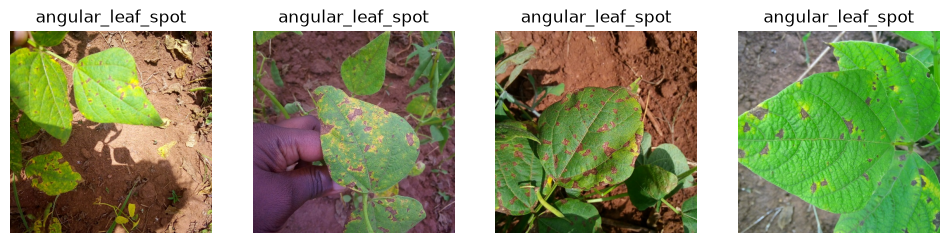

In [6]:
# Peek at a few training examples
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 4, figsize=(12, 3))
for ax, example in zip(axes, dataset["train"].select(range(4))):
    ax.imshow(example["image"])
    ax.set_title(id2label[example["labels"]])
    ax.axis("off")
plt.show()


## Step 3 — Load the Image Processor & Preprocess

`AutoImageProcessor` resizes, normalizes, and formats images exactly the
way the pretrained ViT expects. We wrap it in torchvision transforms and
apply it lazily with `set_transform`.


In [23]:
model_checkpoint = "WinKawaks/vit-small-patch16-224"

image_processor = AutoImageProcessor.from_pretrained(model_checkpoint)

from torchvision.transforms import (
    Compose, Normalize, Resize, ToTensor, RandomHorizontalFlip, CenterCrop,
)

normalize = Normalize(mean=image_processor.image_mean, std=image_processor.image_std)
size = image_processor.size["height"]

train_transforms = Compose([
    Resize((size, size)),
    RandomHorizontalFlip(),
    ToTensor(),
    normalize,
])

val_transforms = Compose([
    Resize((size, size)),
    CenterCrop(size),
    ToTensor(),
    normalize,
])

def preprocess_train(example_batch):
    example_batch["pixel_values"] = [
        train_transforms(img.convert("RGB")) for img in example_batch["image"]
    ]
    return example_batch

def preprocess_val(example_batch):
    example_batch["pixel_values"] = [
        val_transforms(img.convert("RGB")) for img in example_batch["image"]
    ]
    return example_batch

train_ds = dataset["train"]
val_ds = dataset["validation"]
test_ds = dataset["test"]

train_ds.set_transform(preprocess_train)
val_ds.set_transform(preprocess_val)
test_ds.set_transform(preprocess_val)


preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/69.7k [00:00<?, ?B/s]

In [24]:
def collate_fn(examples):
    pixel_values = torch.stack([e["pixel_values"] for e in examples])
    labels = torch.tensor([e["labels"] for e in examples])
    return {"pixel_values": pixel_values, "labels": labels}


## Step 4 — Load the Base ViT Model

This is the pretrained model whose weights we will **freeze**. Only the
LoRA adapters we add next (plus a small classifier head) will be trained.


In [25]:
model = AutoModelForImageClassification.from_pretrained(
    model_checkpoint,
    label2id=label2id,
    id2label=id2label,
    ignore_mismatched_sizes=True,  # classifier head is re-initialized for our 3 classes
)


model.safetensors: reconstructing file:   0%|          |  0.00B / 88.2MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

[transformers] ViTForImageClassification LOAD REPORT from: WinKawaks/vit-small-patch16-224
Key               | Status   |                                                                                          
------------------+----------+------------------------------------------------------------------------------------------
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000, 384]) vs model:torch.Size([3, 384])
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000]) vs model:torch.Size([3])          

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


## Step 5 — Configure LoRA and Wrap the Model

- `r` sets the rank of the trainable low-rank matrices.
- `target_modules` points LoRA at the ViT attention projections (`query`, `value`).
- `modules_to_save` keeps the new classifier head fully trainable (it's tiny
  and task-specific, so there's no reason to restrict it to a low-rank update).

`get_peft_model()` freezes every original ViT parameter and inserts the
trainable adapters. `print_trainable_parameters()` proves how few parameters
will actually receive gradients.


In [26]:
# Uncomment to inspect actual attention layer names on your installed
# transformers version, if target_modules below doesn't pick up any layers:
# for name, _ in model.named_modules():
#     if "attention" in name:
#         print(name)

lora_config = LoraConfig(
    r=32,
    lora_alpha=32,
    target_modules=["query", "value", "q_proj", "v_proj", "dense","o_proj"],
    lora_dropout=0.1,
    bias="none",
    modules_to_save=["classifier"],
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()


trainable params: 885,891 || all params: 22,552,710 || trainable%: 3.9281


## Step 6 — Define the Evaluation Metric

In [27]:
accuracy = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    predictions = np.argmax(eval_pred.predictions, axis=1)
    return accuracy.compute(predictions=predictions, references=eval_pred.label_ids)


## Step 7 — Training Arguments & Trainer

Because most of the model is frozen, this LoRA run needs far less memory
and can use a larger batch size than fine-tuning the full ViT would allow.


In [28]:
args = TrainingArguments(
    output_dir="vit-lora-beans",
    remove_unused_columns=False,

    eval_strategy="epoch",
    save_strategy="epoch",

    learning_rate=2e-3,

    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,

    num_train_epochs=8,

    logging_steps=10,

    load_best_model_at_end=True,
    metric_for_best_model="accuracy",

    label_names=["labels"],
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    data_collator=collate_fn,
    compute_metrics=compute_metrics,
)


## Step 8 — Train

This is the real training loop: forward pass, loss, backward pass, and an
optimizer step on every batch. Gradients only flow into the LoRA `A`/`B`
matrices and the classifier head — the rest of the ViT never updates.


In [29]:
train_results = trainer.train()


/home/dharmateja/.local/lib/python3.11/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy
1,0.557212,0.092056,0.969925
2,0.075689,0.156229,0.947368
3,0.092459,0.062480,0.977444
4,0.233420,0.106933,0.954887
5,0.002747,0.032195,0.977444
6,0.013070,0.069096,0.984962
7,0.001945,0.008687,1.000000
8,0.000039,0.020628,0.984962


/home/dharmateja/.local/lib/python3.11/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/home/dharmateja/.local/lib/python3.11/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/home/dharmateja/.local/lib/python3.11/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/home/dharmateja/.local/lib/python3.11/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/home/dharmateja/.local/lib/python3.11/site-packages/tor

## Step 9 — Evaluate on the Test Set

In [30]:
metrics = trainer.evaluate(test_ds)
print(metrics)


/home/dharmateja/.local/lib/python3.11/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Training Loss,Validation Loss,Epoch,Accuracy
0.000039,0.095001,8,0.984375


{'eval_loss': 0.09500139951705933, 'eval_accuracy': 0.984375}


## Step 10 — Save the Trained Adapter

Only the small trained LoRA weights (plus the classifier head) are saved
here — the frozen base ViT is never re-written to disk.


In [31]:
model.save_pretrained("vit-lora-beans-adapter")

# Optional: push to your own Hugging Face Hub account
# model.push_to_hub("your-username/vit-lora-beans-adapter")


## Step 11 — Reload the Adapter for Inference

Loads a fresh copy of the frozen base model, re-attaches the trained
adapter, and optionally merges it so inference pays no extra latency.


In [34]:
base_model = AutoModelForImageClassification.from_pretrained(
    model_checkpoint,
    label2id=label2id,
    id2label=id2label,
    ignore_mismatched_sizes=True,
)

inference_model = PeftModel.from_pretrained(base_model, "vit-lora-beans-adapter")
inference_model = inference_model.merge_and_unload()
inference_model.eval().to(device)

# Run inference on one test image
sample = dataset["test"][2]
pixel_values = val_transforms(sample["image"].convert("RGB")).unsqueeze(0).to(device)

with torch.no_grad():
    logits = inference_model(pixel_values=pixel_values).logits

predicted_label = id2label[logits.argmax(-1).item()]
print("Predicted:", predicted_label, "| Actual:", id2label[sample["labels"]])


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

[transformers] ViTForImageClassification LOAD REPORT from: WinKawaks/vit-small-patch16-224
Key               | Status   |                                                                                          
------------------+----------+------------------------------------------------------------------------------------------
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000, 384]) vs model:torch.Size([3, 384])
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000]) vs model:torch.Size([3])          

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


Predicted: angular_leaf_spot | Actual: angular_leaf_spot


## Summary

- We froze a pretrained ViT and trained only LoRA `A`/`B` matrices (plus a
  small classifier head) — a real gradient-descent training run.
- `LoraConfig` + `get_peft_model()` did the freezing and adapter insertion;
  `Trainer.train()` ran the actual optimization loop.
- The saved artifact is a small adapter, not a full model checkpoint.
- `PeftModel.from_pretrained()` + `merge_and_unload()` bring the trained
  adapter back for zero-overhead inference.

**Next steps to try:**
- Sweep `r` and `lora_alpha` to trade off capacity vs. adapter size.
- Try a bigger/harder dataset (e.g. `food101`, `cifar100`).
- Compare training time/memory against full fine-tuning of the same ViT.
